In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cns.data_utils import load_all_samples, save_cns_fig, load_merged_samples
from cns.utils.kneepoint import count_below_lim, find_knee, count_cum_val

In [3]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [4]:
data = load_all_samples(False, False, False, True)
data["combined"] = load_merged_samples(False, False, False)
datasets = list(data.keys())
print(datasets)
colors = {"PCAWG": "C0", "TCGA_hg19": "C1", "TRACERx": "C2", "combined": "gray"}

['PCAWG', 'TRACERx', 'TCGA_hg19', 'combined']


In [5]:
ane_Y_raw = {}
ane_Y = {}
ane_X = {}
feature = "ane_het_aut"   
max_val = 1
for k, v in data.items():
    ane_X[k], ane_Y[k] = count_below_lim(v[feature], steps=10000)    

PCAWG 137.0 9 44.25738296252843
TRACERx 0.0 1 0
TCGA_hg19 703.0 3 45.02643770077974
combined 746.0 3 44.6756827564358


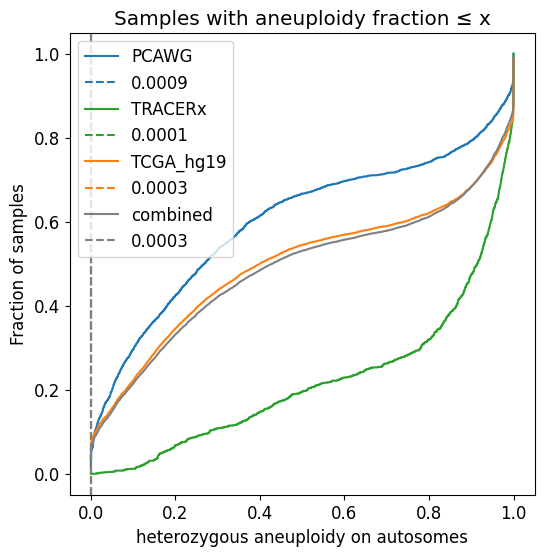

In [6]:
for k in datasets:
    plt.plot(ane_X[k], ane_Y[k], label=k, color=colors[k])    
    knee_index, knee_value = find_knee(ane_X[k], ane_Y[k], knee=True)
    sample_c = ane_Y[k][knee_index] * len(data[k])
    print(k, sample_c, knee_index, knee_value)
    x_pos = ane_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

PCAWG 137.0 9 44.25738296252843
TRACERx 0.0 1 0
TCGA_hg19 703.0 3 45.02643770077974
combined 746.0 3 44.6756827564358


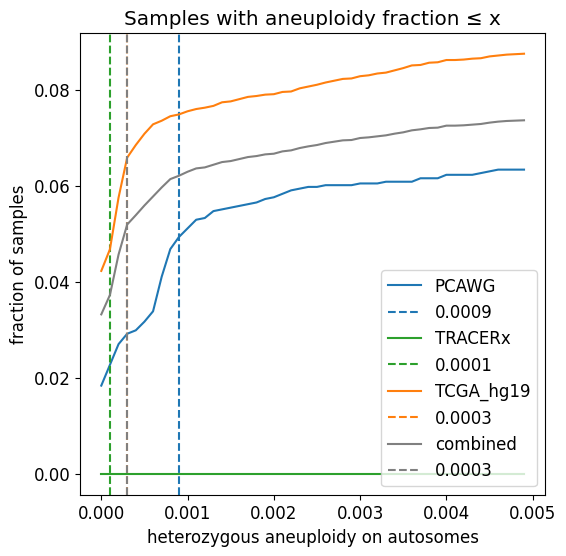

In [7]:
for k in datasets:
    lim = 50
    plt.plot(ane_X[k][:lim], ane_Y[k][:lim], label=k, color=colors[k])    
    knee_index, knee_value = find_knee(ane_X[k], ane_Y[k], knee=True)
    sample_c = ane_Y[k][knee_index] * len(data[k])
    print(k, sample_c, knee_index, knee_value)
    x_pos = ane_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")
    
plt.xlabel("heterozygous aneuploidy on autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with aneuploidy fraction ≤ x")
save_cns_fig(f"fig_samples_aneuploidy_fraction_lim")

In [8]:
cov_Y = {}
cov_X = {}
feature = "cover_het_aut"
min_val = 0
for k, v in data.items():
    cov_X[k], cov_Y[k] = count_below_lim(v[feature], min_val=min_val, steps=10000)

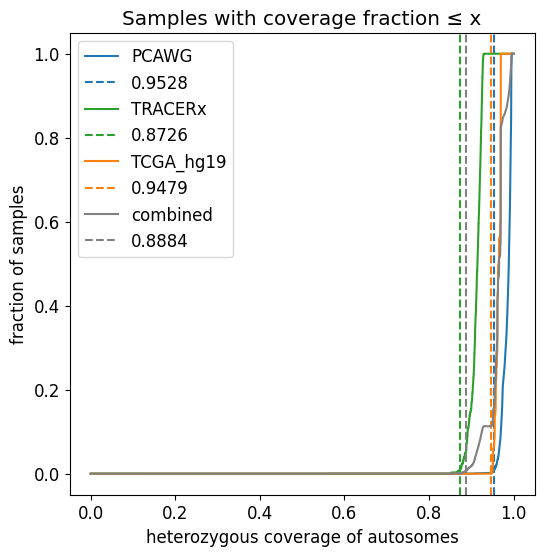

In [9]:
for k in datasets:
    plt.plot(cov_X[k], cov_Y[k], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(cov_X[k],  cov_Y[k], knee=False)
    x_pos = cov_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
save_cns_fig(f"fig_samples_coverage_fraction")

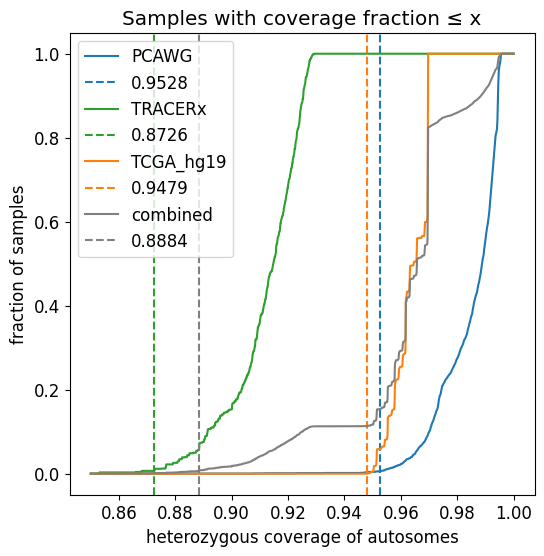

In [10]:
for k in datasets:
    lim = 8500
    plt.plot(cov_X[k][lim:], cov_Y[k][lim:], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(cov_X[k],  cov_Y[k], knee=False)
    x_pos = cov_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{x_pos:.4f}")

plt.xlabel("heterozygous coverage of autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with coverage fraction ≤ x")
save_cns_fig(f"fig_samples_coverage_fraction_lim")

In [11]:
break_Y = {}
break_X = {}
break_deltas = {}
feature = "breaks_total_cn_aut"
steps = np.max([np.max(v[feature]) for v in data.values()])
print(steps)
for k, v in data.items():
    break_X[k], break_Y[k] = count_below_lim(v[feature], max_val=steps, steps=steps)

1741


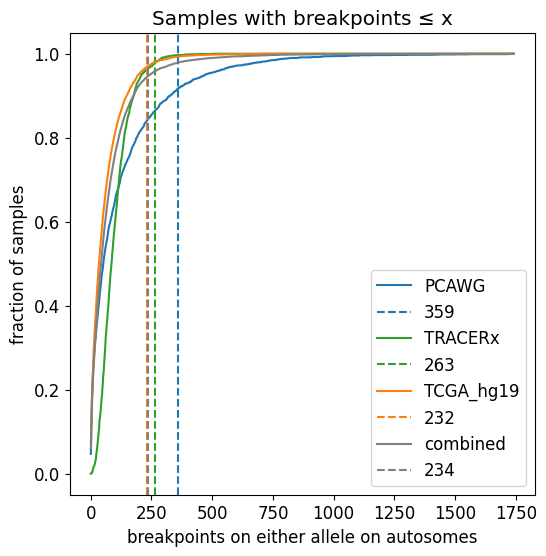

In [12]:
for k in datasets:
    plt.plot(break_X[k], break_Y[k], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(break_X[k], break_Y[k], knee=True)
    x_pos = break_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{int(x_pos)}")

plt.ylabel("fraction of samples")
plt.xlabel("breakpoints on either allele on autosomes")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
save_cns_fig(f"fig_samples_breakpoints")

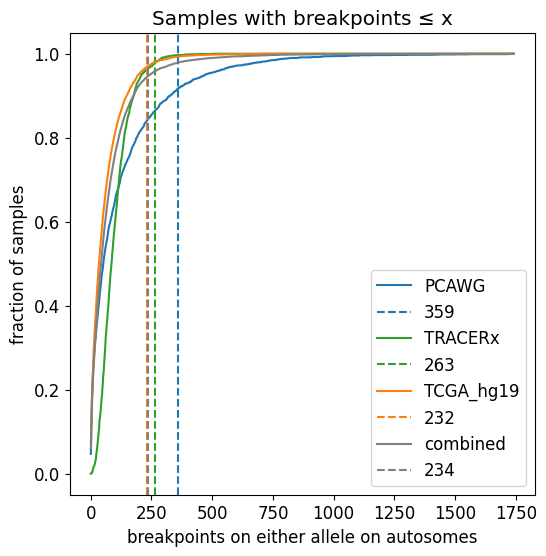

In [13]:
for k in datasets:
    plt.plot(break_X[k][:lim], break_Y[k][:lim], label=k, color=colors[k])        
    knee_index, knee_value = find_knee(break_X[k], break_Y[k], knee=True)
    x_pos = break_X[k][knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--", label=f"{int(x_pos)}")

plt.ylabel("fraction of samples")
plt.xlabel("breakpoints on either allele on autosomes")
plt.title(f"Samples with breakpoints ≤ x")
plt.legend()
save_cns_fig(f"fig_samples_breakpoints_lim")

In [14]:
def plot_feature(feature, label, data, min_val=None, max_val=None):
    min_val = np.min([np.min(v[feature]) for v in data.values()]) if min_val is None else min_val
    max_val = np.max([np.max(v[feature]) for v in data.values()]) if max_val is None else max_val
    for k, v in data.items():
        ane_X[k], ane_Y[k] = count_below_lim(v[feature], min_val, max_val, steps=10000)    
        plt.plot(ane_X[k], ane_Y[k], label=k, color=colors[k])    
        
    plt.xlabel(f"{label} value")
    plt.ylabel("fraction of samples")
    plt.legend()
    plt.title(f"Samples with {label} fraction ≤ x")    
    save_cns_fig(f"fig_samples_{feature}")

In [15]:
data["combined"].columns

Index(['sex', 'type', 'chrom_count', 'chrom_missing', 'cover_hom_aut',
       'cover_hom_sex', 'cover_hom_all', 'cover_het_aut', 'cover_het_sex',
       'cover_het_all', 'ane_het_aut', 'ane_het_sex', 'ane_het_all',
       'ane_hom_aut', 'ane_hom_sex', 'ane_hom_all', 'loh_het_aut',
       'loh_het_sex', 'loh_het_all', 'loh_hom_aut', 'loh_hom_sex',
       'loh_hom_all', 'imb_major_cn_aut', 'imb_major_cn_sex',
       'imb_major_cn_all', 'breaks_major_cn_aut', 'breaks_major_cn_sex',
       'breaks_major_cn_all', 'step_major_cn_aut', 'step_major_cn_sex',
       'step_major_cn_all', 'segsize_major_cn_aut', 'segsize_major_cn_sex',
       'segsize_major_cn_tot', 'breaks_minor_cn_aut', 'breaks_minor_cn_sex',
       'breaks_minor_cn_all', 'step_minor_cn_aut', 'step_minor_cn_sex',
       'step_minor_cn_all', 'segsize_minor_cn_aut', 'segsize_minor_cn_sex',
       'segsize_minor_cn_tot', 'breaks_total_cn_aut', 'breaks_total_cn_sex',
       'breaks_total_cn_all', 'step_total_cn_aut', 'step_total_cn_

Text(0.5, 18.825000000000003, 'heterozygous LOH on autosomes')

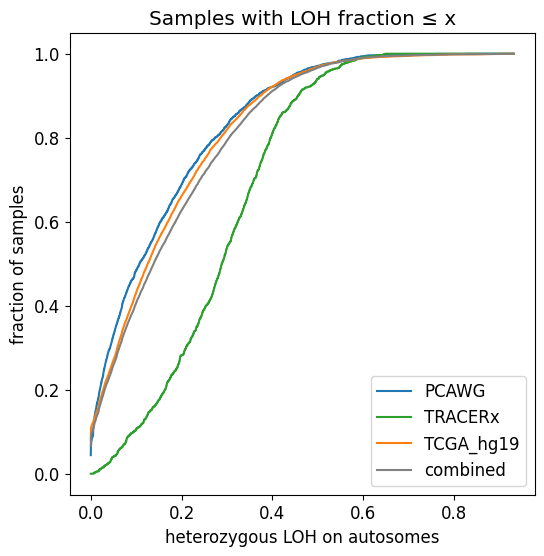

In [16]:
plot_feature("loh_het_aut", "LOH", data)
plt.xlabel("heterozygous LOH on autosomes")

Text(0.5, 18.825000000000003, 'Average step between breakpoints on autosomes')

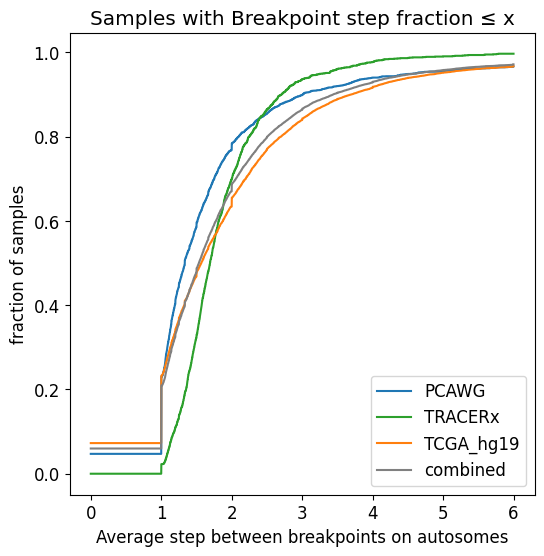

In [17]:
plot_feature("step_total_cn_aut", "Breakpoint step", data, max_val = 6)
plt.xlabel("Average step between breakpoints on autosomes")

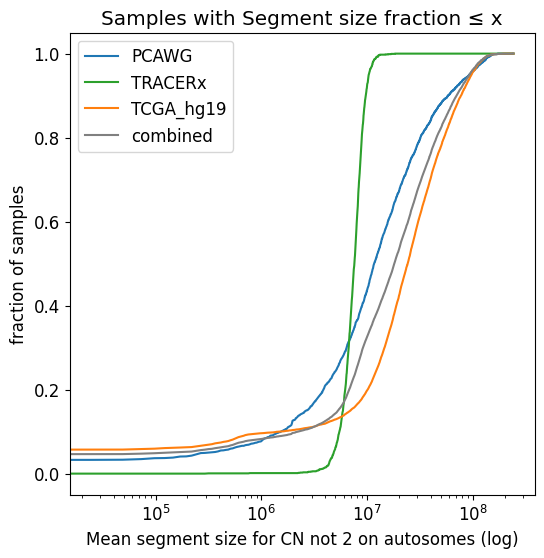

In [18]:
plot_feature("segsize_total_cn_aut", "Segment size", data)
plt.xlabel("Mean segment size for CN not 2 on autosomes (log)")
plt.xscale("log")